# Video: Visualizing with a Grand Tour

In this video, you will see the grand tour visualization technique used to see the variety of possible linear dimensionality reductions.

[![View on GitHub](https://img.shields.io/badge/GitHub-181717?logo=github&logoColor=white)](https://github.com/bu-cds-omds/dx601-examples/blob/main/week13/video_visualizing_with_a_grand_tour.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bu-cds-omds/dx601-examples/blob/main/week13/video_visualizing_with_a_grand_tour.ipynb)



Script: (faculty on screen)
* Most data sets have more than two columns, so we are forced to make choices in how to plot it.
* Should we pick two columns to plot?
* Should we plot the first two principal components?
* Does the data set have any direction with a useful separation?
* In this video, we will use the grand tour technique to systematically explore all directions.

In [ ]:
!pip install datatour kaleido==0.2.1 plotly==6.1.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 62.4 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


In [ ]:
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.io as pio

from datatour import DataTour
from kaleido.scopes.plotly import PlotlyScope
from sklearn.datasets import load_iris


## Example Iris Data (Fisher, 1936)


In [ ]:
# 1. Load Iris data and format as a pandas DataFrame
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Display the first few rows of the nicely formatted table
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Script:
* To demonstrate grand tours, we will use the iris data set collected by Ronald Fisher.
* It has four input columns with flower measurements, and one target identifying one of three species.

## Grand Tour Visualizations (Asimov, 1985)

V1: Understand the data by looking at it from **every** angle.

V2: Understand the data by looking at it from **close** to every angle.

Script:
* Grand tour visualizations were invented by Daniel Asimov.
* The basic idea is to look at the data from every possible angle.
* As the tour visits every possible angle, watch for an angle with a useful separation.
* This idea is not possible, since there are an infinite number of possible angles.
* However, we can design a sequence of angles that passes close to every possible angle which is possible.

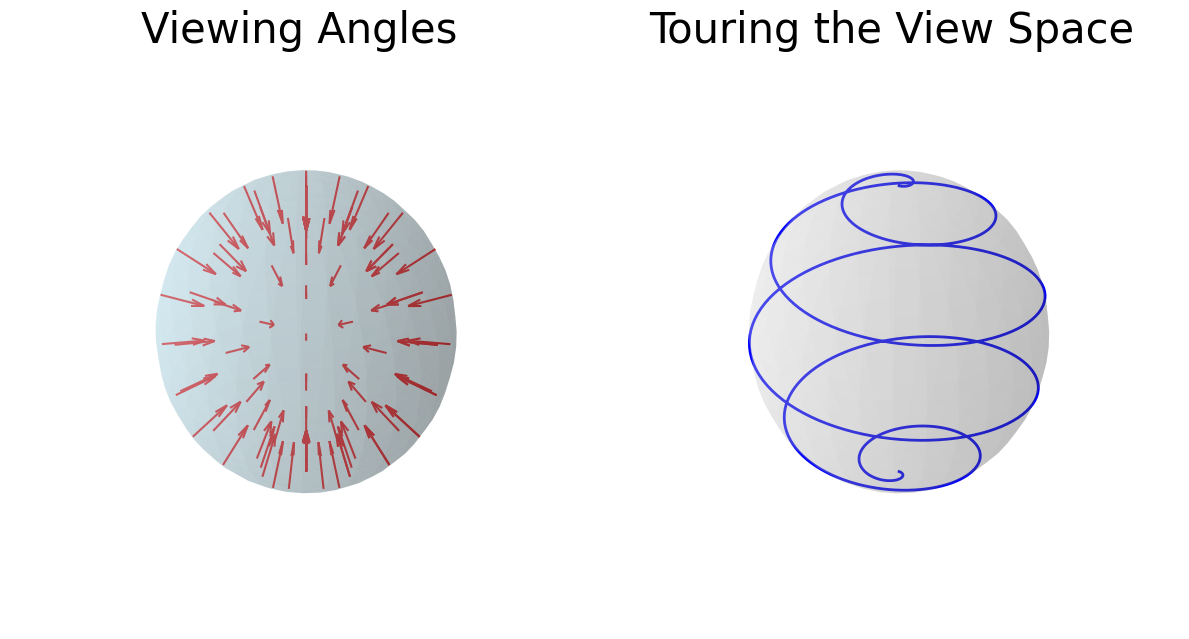

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 3D figure with two subplots
fig = plt.figure(figsize=(12, 8))

# --- Subplot 1: Sphere with Inward Arrows ---
ax1 = fig.add_subplot(121, projection='3d')

# Sphere surface data
u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 30)
x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))

ax1.plot_surface(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.3, linewidth=0)

# Arrow data
u_arrow = np.linspace(0, 2 * np.pi, 10)
v_arrow = np.linspace(0, np.pi, 10)
x_a = np.outer(np.cos(u_arrow), np.sin(v_arrow)).flatten()
y_a = np.outer(np.sin(u_arrow), np.sin(v_arrow)).flatten()
z_a = np.outer(np.ones(np.size(u_arrow)), np.cos(v_arrow)).flatten()

ax1.quiver(x_a, y_a, z_a, -x_a, -y_a, -z_a, length=0.3, color='red', normalize=True)
ax1.set_axis_off()
ax1.set_box_aspect([1,1,1])
# Update title and increase size
ax1.set_title("Viewing Angles", fontsize=30)

# --- Subplot 2: Spiral over Sphere Surface ---
ax2 = fig.add_subplot(122, projection='3d')

# Draw sphere surface again for context
ax2.plot_surface(x_sphere, y_sphere, z_sphere, color='lightgrey', alpha=0.2, linewidth=0)

# Create spiral path
t = np.linspace(0, np.pi, 500) # From top to bottom
phi = 10 * t                   # Number of rotations
x_spiral = np.sin(t) * np.cos(phi)
y_spiral = np.sin(t) * np.sin(phi)
z_spiral = np.cos(t)

ax2.plot(x_spiral, y_spiral, z_spiral, color='blue', linewidth=2, label='Spiral Path')
ax2.set_axis_off()
ax2.set_box_aspect([1,1,1])
# Update title and increase size
ax2.set_title("Touring the View Space", fontsize=30)

plt.tight_layout()
plt.show()

Script:
* What are all the possible viewing angles?
* Think of them as all the points on the surface of a sphere of the same dimension.
* This glosses over orienting which point is up in your view, but will suffice for now.
* The grand tour systematically covers the view space to come close to every view.

## Space Filling Curves (Peano 1890)


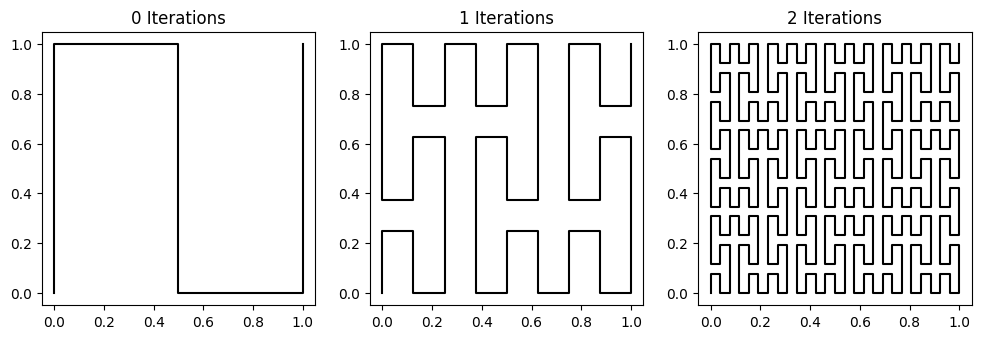

In [ ]:
xs = []
ys = []

def prepare_peano_curve(x0, y0, x1, y1, n):
    subdivisions = 3 ** (n + 1) - 1

    assert np.isclose(abs(x1 - x0), abs(y1 - y0))

    dx = (x1 - x0) / subdivisions
    dy = (y1 - y0) / subdivisions

    if n <= 0:
        xs.extend([x0, x0, (x0+x1)/2, (x0+x1)/2, x1, x1])
        ys.extend([y0, y1, y1, y0, y0, y1])
    else:
        boundaries = [0, 3 ** n - 1, 3 ** n, 2 * 3 ** n - 1, 2 * 3 ** n, 3 * 3 ** n - 1]
        assert boundaries[-1] == subdivisions

        def recurse(i0, j0, i1, j1):
            assert 0 <= i0 <= 5
            assert 0 <= i1 <= 5
            assert 0 <= j0 <= 5
            assert 0 <= j1 <= 5
            prepare_peano_curve(x0 + dx * boundaries[i0],
                                y0 + dy * boundaries[j0],
                                x0 + dx * boundaries[i1],
                                y0 + dy * boundaries[j1],
                                n - 1)

        recurse(0, 0, 1, 1) # 0
        recurse(1, 2, 0, 3) # 1
        recurse(0, 4, 1, 5) # 2

        recurse(2, 5, 3, 4) # 3
        recurse(3, 3, 2, 2) # 4
        recurse(2, 1, 3, 0) # 5

        recurse(4, 0, 5, 1) # 6
        recurse(5, 2, 4, 3) # 7
        recurse(4, 4, 5, 5) # 8

plt.figure(figsize=(12, 4))

for levels in [0, 1, 2]:
    plt.subplot(1, 3, levels + 1)

    xs = []
    ys = []
    prepare_peano_curve(0, 0, 1, 1, levels) #3 ** (levels + 1) - 1, 3 ** (levels + 1) - 1, levels)
    plt.plot(xs, ys, 'k-')

    plt.gca().set_aspect('equal')
    plt.grid(False)
    plt.title(f"{levels} Iterations")

plt.show()

Script:
* There are many ways to design grand tours, but I think of them as following a space filling curve through the view space.
* These particular space filling curves are due to Giuseppe Peano in 1890.
* Starting from the first simple path, that curve is recursively repeated to get a finer and finer path that passes closer and closer to every path.
* This curve is designed for a square space, but there are many different space filling curves and they can be designed for different shaped spaces like the sphere of viewing angles.

In [ ]:
# 2. Initialize DataTour
# data: 2d array [sample_idx, feature_idx]
# labels: 1d array [sample_idx] of class indices
tour = DataTour(data=X, labels=y, norm='std')

Found 6 mtx for 4-dimensional rotations in cache. 0 will be generated
[1 4 3 5 0 2]
rot=0
rot=1
rot=2
rot=3
rot=4


## A Grand Tour of the Iris Data Set


In [ ]:
# 3. Display the animation
# color='l' tells datatour to use the provided labels for color coding
tour.display(color='l', point_size=10, fig_size=600)

Script:
* Here is a grand tour of the iris data set.
* Each species of iris has its own color, so we can easily see when a projection on the tour separates them nicely.
* Some views overlap the species more than others, but many of them look useful.
* By watching the grand tour, you can gauge the probability that a random view will be useful.

In [ ]:
# Ensure the figure exists
if hasattr(tour, 'last_fig') and tour.last_fig is not None:
    print("Initializing Kaleido scope...")
    # Explicitly use the 0.2.1 scope logic
    scope = PlotlyScope()

    fig = tour.last_fig
    frames = []

    total_frames = len(fig.frames)
    print(f"Exporting {total_frames} frames to MP4...")

    # Iterate through the frames in the Plotly figure
    for i, frame in enumerate(fig.frames):
        # Update the figure data to this frame
        fig.update(data=frame.data)

        # Transform figure to PNG bytes
        img_bytes = scope.transform(fig, format="png")

        nparr = np.frombuffer(img_bytes, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
        frames.append(img)
        if i % 20 == 0:
            print(f"Processed frame {i}/{total_frames}")

    # Write to video
    if frames:
        height, width, layers = frames[0].shape
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        video = cv2.VideoWriter('iris_tour.mp4', fourcc, 10, (width, height))

        for frame in frames:
            video.write(frame)

        video.release()
        print("Success! Animation saved as iris_tour.mp4")
else:
    print("No figure found. Please run the tour.display() cell first.")

Initializing Kaleido scope...
Exporting 450 frames to MP4...
Processed frame 0/450
Processed frame 20/450
Processed frame 40/450
Processed frame 60/450
Processed frame 80/450
Processed frame 100/450
Processed frame 120/450
Processed frame 140/450
Processed frame 160/450
Processed frame 180/450
Processed frame 200/450
Processed frame 220/450
Processed frame 240/450
Processed frame 260/450
Processed frame 280/450
Processed frame 300/450
Processed frame 320/450
Processed frame 340/450
Processed frame 360/450
Processed frame 380/450
Processed frame 400/450
Processed frame 420/450
Processed frame 440/450
Success! Animation saved as iris_tour.mp4


Script: (faculty on screen)
* Random projections are a dimensionality reduction technique with theory to say they are often useful.
* Grand tours give a way to see that distribution of views and eyeball the probability that a random view is useful.